# Kalp Yetmezliği Tahmini: Makine Öğrenmesi Yaklaşımı

 Zahraa Mahdi Salih Alhaji  
 



## 1. Veri Seti Tanıtımı ve Veri Analizi

In [1]:
# Gerekli kütüphaneler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')# Color palette
NAVY = '#1B2A4A'
DARK_GREY = '#4A4A4A'
CORAL = '#D65B5B'
SOFT_CORAL = '#E8836B'
LIGHT_NAVY = '#2C4A7C'
CREAM = '#F5F0EB'
MID_GREY = '#8A8A8A'
TEAL = '#2A7A7A'
GREEN = '#3A7A5A'


In [2]:
# Veri setini yükle
VERI_YOLU = Path("heart_failure_clinical_records_dataset.csv")
df = pd.read_csv(VERI_YOLU)
print("Veri seti başarıyla yüklendi.")

Veri seti başarıyla yüklendi.


In [3]:
# Veri setinin genel yapısı
print("="*60)
print("VERİ SETİ BOYUTU")
print("="*60)
print(f"Satır sayısı (hasta sayısı): {df.shape[0]}")
print(f"Sütun sayısı (özellik sayısı): {df.shape[1]}")
print()

print("="*60)
print("SÜTUN İSİMLERİ VE VERİ TİPLERİ")
print("="*60)
print(df.dtypes.to_string())
print()

print("="*60)
print("İLK 5 SATIR")
print("="*60)
df.head()

# Özellik tablosu (Tablo 2 benzeri)
print("\n" + "="*80)
print("VERİ SETİ ÖZELLİK TANIM TABLOSU")
print("="*80)
ozellik_tanimi = pd.DataFrame({
    'Özellik': ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
                'ejection_fraction', 'high_blood_pressure', 'platelets',
                'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time'],
    'Tür': ['Sayısal', 'Kategorik', 'Sayısal', 'Kategorik',
            'Sayısal', 'Kategorik', 'Sayısal', 'Sayısal',
            'Sayısal', 'Kategorik', 'Kategorik', 'Sayısal'],
    'Birim': ['Yıl', '0/1', 'mcg/L', '0/1',
              '%', '0/1', 'kilopL', 'mg/dL',
              'mEq/L', '0/1', '0/1', 'Gün'],
    'Açıklama': ['Hasta yaşı', 'Kansızlık varlığı', 'Kreatinin fosfokinaz seviyesi', 'Diyabet varlığı',
                 'Ejeksiyon fraksiyonu', 'Yüksek tansiyon varlığı', 'Trombosit sayısı', 'Serum kreatinin seviyesi',
                 'Serum sodyum seviyesi', 'Cinsiyet', 'Sigara kullanımı', 'Takip süresi']
})
print(ozellik_tanimi.to_string(index=False))


VERİ SETİ BOYUTU
Satır sayısı (hasta sayısı): 299
Sütun sayısı (özellik sayısı): 13

SÜTUN İSİMLERİ VE VERİ TİPLERİ
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64

İLK 5 SATIR

VERİ SETİ ÖZELLİK TANIM TABLOSU
                 Özellik       Tür  Birim                      Açıklama
                     age   Sayısal    Yıl                    Hasta yaşı
                 anaemia Kategorik    0/1             Kansızlık varlığı
creatinine_phosphokinase   Sayısal  mcg/L Kreatinin fosfokinaz seviyesi
                diabetes Kategorik    0/1               Diyabet varlığı
       eje

In [4]:
# Eksik veri kontrolü
print("="*60)
print("EKSİK VERİ KONTROLÜ")
print("="*60)
print(df.isnull().sum().to_string())
print()
print(f"Toplam eksik hücre sayısı: {df.isnull().sum().sum()}")

EKSİK VERİ KONTROLÜ
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0

Toplam eksik hücre sayısı: 0


In [5]:
# Temel istatistiksel analiz (Betimsel Analiz)
print("="*60)
print("TEMEL İSTATİSTİKLER (BETİMSEL ANALİZ)")
print("="*60)
df.describe().T

TEMEL İSTATİSTİKLER (BETİMSEL ANALİZ)


,count,mean,std,min,25%,50%,75%,max
age,299.0,60.833893,11.894809,40.0,51.0,60.0,70.0,95.0
anaemia,299.0,0.431438,0.496107,0.0,0.0,0.0,1.0,1.0
creatinine_phosphokinase,299.0,581.839465,970.287881,23.0,116.5,250.0,582.0,7861.0
diabetes,299.0,0.418060,0.494067,0.0,0.0,0.0,1.0,1.0
ejection_fraction,299.0,38.083612,11.834841,14.0,30.0,38.0,45.0,80.0
high_blood_pressure,299.0,0.351171,0.478136,0.0,0.0,0.0,1.0,1.0
platelets,299.0,263358.029264,97804.236869,25100.0,212500.0,262000.0,303500.0,850000.0
serum_creatinine,299.0,1.393880,1.034510,0.5,0.9,1.1,1.4,9.4
serum_sodium,299.0,136.625418,4.412477,113.0,134.0,137.0,140.0,148.0
sex,299.0,0.648829,0.478136,0.0,0.0,1.0,1.0,1.0


In [6]:
# Hedef değişken dağılımı
print("="*60)
print("HEDEF DEĞİŞKEN DAĞILIMI (DEATH_EVENT)")
print("="*60)
hedef_dagilim = df['DEATH_EVENT'].value_counts()
print(f"Hayatta kalan (0): {hedef_dagilim[0]} hasta ({hedef_dagilim[0]/len(df)*100:.1f}%)")
print(f"Hayatını kaybeden (1): {hedef_dagilim[1]} hasta ({hedef_dagilim[1]/len(df)*100:.1f}%)")

HEDEF DEĞİŞKEN DAĞILIMI (DEATH_EVENT)
Hayatta kalan (0): 203 hasta (67.9%)
Hayatını kaybeden (1): 96 hasta (32.1%)


In [ ]:
# Şekil 1: DEATH_EVENT Dağılımı (DOCX stili)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5))
fig.patch.set_facecolor('white')
counts = df['DEATH_EVENT'].value_counts()
labels_bar = ['Hayatta Kalan\n(0)', 'Ölen\n(1)']
colors_bar = [NAVY, CORAL]
bars = ax1.bar(labels_bar, counts.values, color=colors_bar, width=0.55, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4, str(val),
             ha='center', va='bottom', fontsize=14, fontweight='bold', color=DARK_GREY)
ax1.set_ylabel('Hasta Say\u0131s\u0131', fontsize=12, fontweight='bold', color=DARK_GREY)
ax1.set_title('(a) Frekans Da\u011f\u0131l\u0131m\u0131', fontsize=14, fontweight='bold', color=NAVY, pad=10)
ax1.set_ylim(0, 260)
ax1.tick_params(colors=DARK_GREY, labelsize=11)
for spine in ax1.spines.values(): spine.set_visible(False)

pcts = df['DEATH_EVENT'].value_counts(normalize=True) * 100
wedges, _, _ = ax2.pie(pcts.values, labels=None, autopct='', startangle=90,
    colors=[NAVY, CORAL], explode=(0, 0.07),
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5, 'width': 0.6})
for i, (pct, count) in enumerate(zip(pcts.values, counts.values)):
    ang = (wedges[i].theta2 + wedges[i].theta1) / 2
    x = 0.85 * np.cos(np.deg2rad(ang))
    y = 0.85 * np.sin(np.deg2rad(ang))
    ax2.text(x, y, f'{pct:.1f}%', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    ax2.text(x*0.45, y*0.45, f'n={count}', ha='center', va='center', fontsize=10, fontweight='bold', color='white')
ax2.set_title('(b) Y\u00fczde Da\u011f\u0131l\u0131m', fontsize=14, fontweight='bold', color=NAVY, pad=10)
ax2.legend([f'Hayatta Kalan (0): {counts[0]} hasta', f'\u00d6len (1): {counts[1]} hasta'],
    loc='lower center', bbox_to_anchor=(0.5, -0.12), fontsize=10)
fig.suptitle('\u015eekil 1: Hedef De\u011fi\u015fken (DEATH_EVENT) Da\u011f\u0131l\u0131m ve S\u0131n\u0131f Dengesi', fontsize=15, fontweight='bold', color=NAVY, y=1.02)
plt.tight_layout()
plt.show()

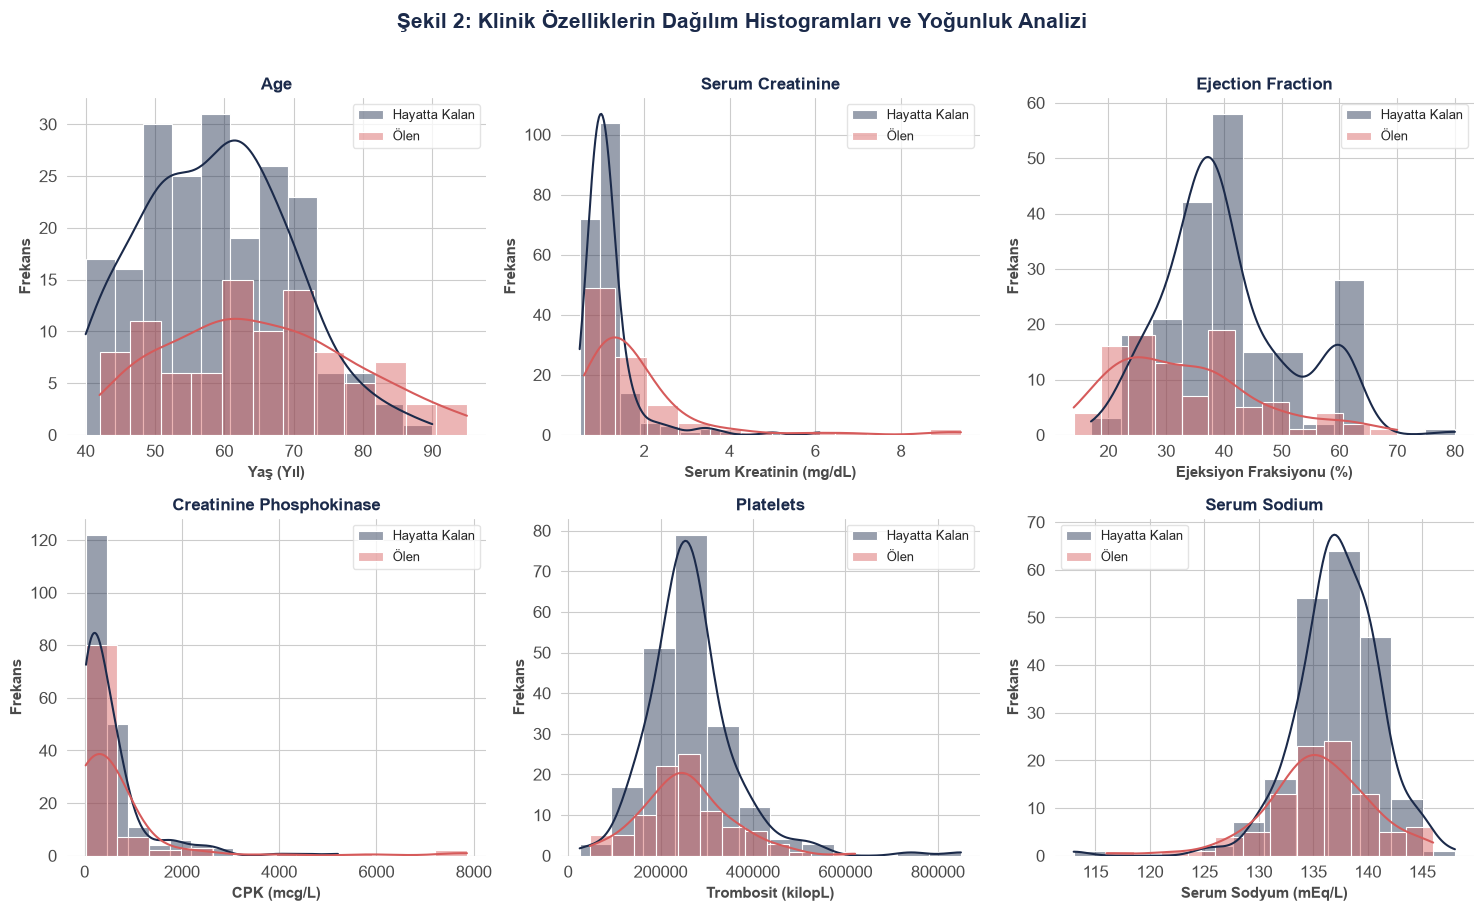

In [ ]:
# \u015eekil 2: Klinik \u00d6zelliklerin Da\u011f\u0131l\u0131m Histogramlar\u0131 (DOCX stili)
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.patch.set_facecolor('white')
feats1 = [('age', 'Ya\u015f (Y\u0131l)'), ('serum_creatinine', 'Serum Kreatinin (mg/dL)'), ('ejection_fraction', 'Ejeksiyon Fraksiyonu (%)')]
feats2 = [('creatinine_phosphokinase', 'CPK (mcg/L)'), ('platelets', 'Trombosit (kilopL)'), ('serum_sodium', 'Serum Sodyum (mEq/L)')]
for idx, (col, xlbl) in enumerate(feats1):
    ax = axes[0, idx]
    for cls, c, lbl in [(0, NAVY, 'Hayatta Kalan'), (1, CORAL, '\u00d6len')]:
        sub = df[df['DEATH_EVENT'] == cls][col].dropna()
        sns.histplot(sub, kde=True, color=c, label=lbl, ax=ax, alpha=0.45, bins=12, edgecolor='white', linewidth=0.8)
    ax.set_xlabel(xlbl, fontsize=11, fontweight='bold', color=DARK_GREY)
    ax.set_ylabel('Frekans', fontsize=11, fontweight='bold', color=DARK_GREY)
    ax.set_title(col.replace('_',' ').title(), fontsize=12, fontweight='bold', color=NAVY)
    ax.legend(fontsize=9, frameon=True, facecolor='white', edgecolor='#ddd')
    ax.tick_params(colors=DARK_GREY)
    for s in ax.spines.values(): s.set_visible(False)
for idx, (col, xlbl) in enumerate(feats2):
    ax = axes[1, idx]
    for cls, c, lbl in [(0, NAVY, 'Hayatta Kalan'), (1, CORAL, '\u00d6len')]:
        sub = df[df['DEATH_EVENT'] == cls][col].dropna()
        sns.histplot(sub, kde=True, color=c, label=lbl, ax=ax, alpha=0.45, bins=12, edgecolor='white', linewidth=0.8)
    ax.set_xlabel(xlbl, fontsize=11, fontweight='bold', color=DARK_GREY)
    ax.set_ylabel('Frekans', fontsize=11, fontweight='bold', color=DARK_GREY)
    ax.set_title(col.replace('_',' ').title(), fontsize=12, fontweight='bold', color=NAVY)
    ax.legend(fontsize=9, frameon=True, facecolor='white', edgecolor='#ddd')
    ax.tick_params(colors=DARK_GREY)
    for s in ax.spines.values(): s.set_visible(False)
fig.suptitle('\u015eekil 2: Klinik \u00d6zelliklerin Da\u011f\u0131l\u0131m Histogramlar\u0131 ve Yo\u011funluk Analizi', fontsize=15, fontweight='bold', color=NAVY, y=1.01)
plt.tight_layout()
plt.show()

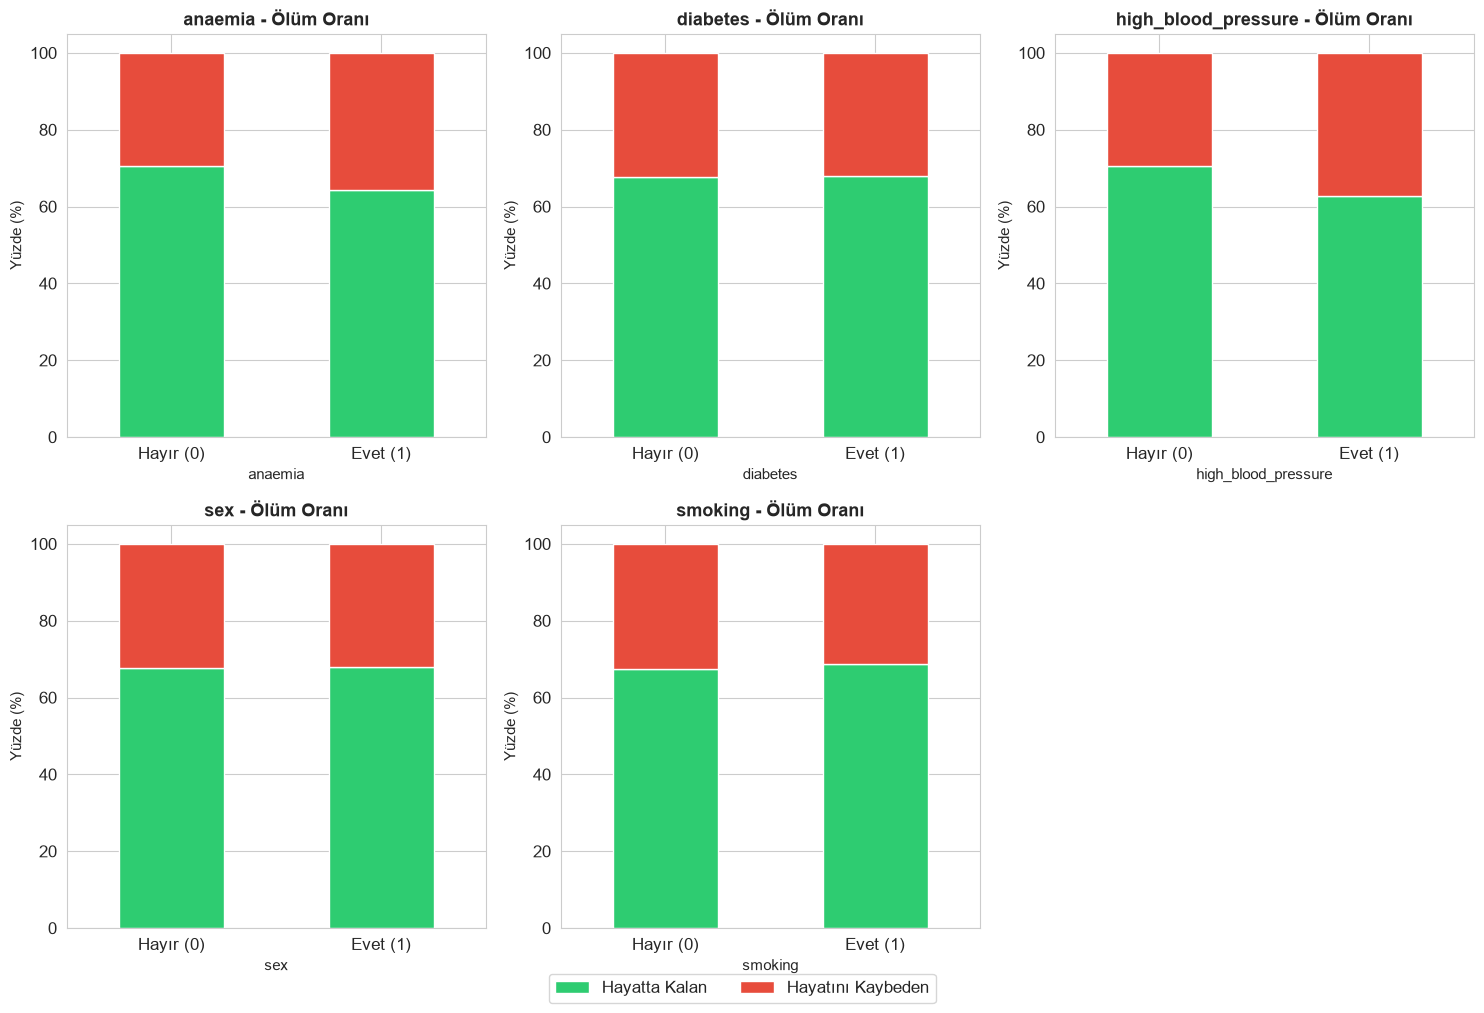

In [ ]:
# Kategorik özelliklerin hedef değişkene göre analizi
kategorik_ozellikler = ['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, ozellik in enumerate(kategorik_ozellikler):
    tablo = pd.crosstab(df[ozellik], df['DEATH_EVENT'], normalize='index') * 100
    tablo.plot(kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'],
               ax=axes[i], legend=False)
    axes[i].set_title(f'{ozellik} - Ölüm Oranı', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(ozellik, fontsize=11)
    axes[i].set_ylabel('Yüzde (%)', fontsize=11)
    axes[i].set_xticklabels(['Hayır (0)', 'Evet (1)'], rotation=0)

for j in range(len(kategorik_ozellikler), 6):
    axes[j].set_visible(False)

fig.legend(['Hayatta Kalan', 'Hayatını Kaybeden'], loc='lower center',
           ncol=2, fontsize=12, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()

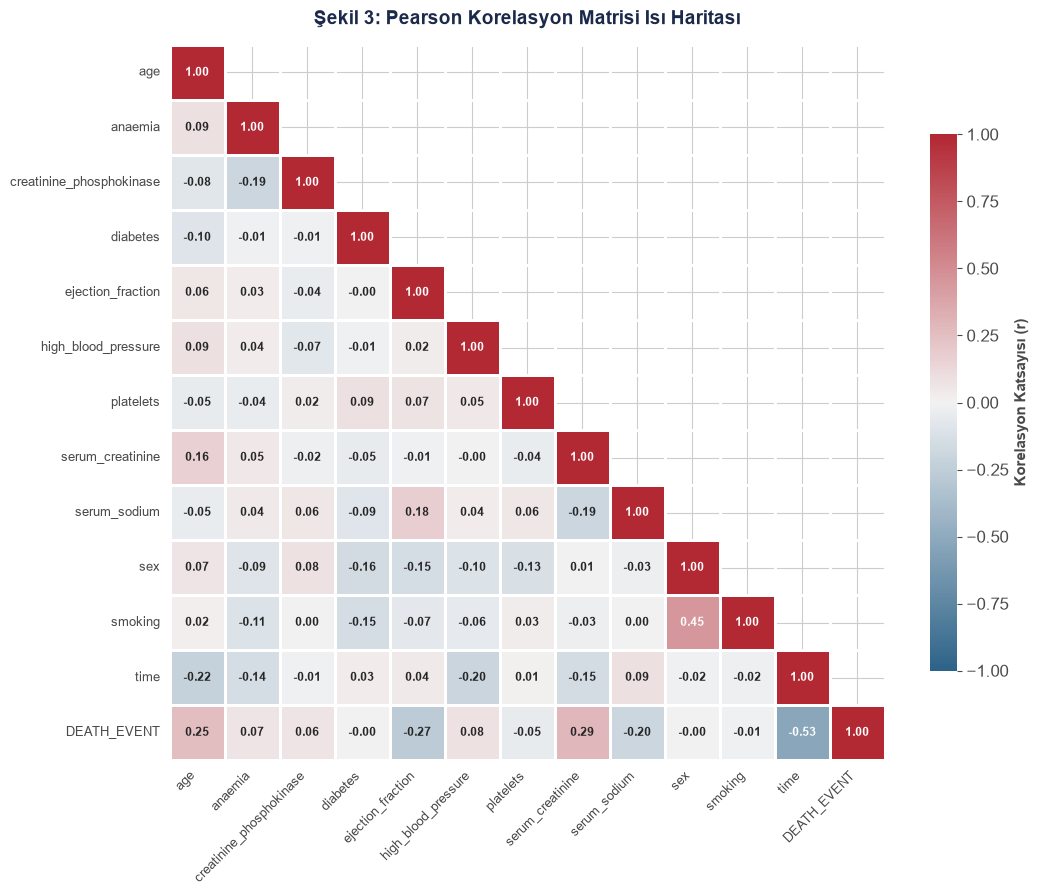

In [ ]:
# \u015eekil 3: Pearson Korelasyon Matrisi (DOCX stili)
fig, ax = plt.subplots(figsize=(11, 9))
fig.patch.set_facecolor('white')
corr = df.corr(method='pearson')
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
cmap = sns.diverging_palette(240, 10, as_cmap=True, s=80, l=40)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap=cmap, center=0,
    vmin=-1, vmax=1, square=True, linewidths=0.8, linecolor='white',
    cbar_kws={'shrink': 0.75, 'label': 'Pearson r'},
    annot_kws={'fontsize': 8.5, 'fontweight': 'bold'}, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9, color=DARK_GREY)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9, color=DARK_GREY)
ax.set_title('\u015eekil 3: Pearson Korelasyon Matrisi Is\u0131 Haritas\u0131', fontsize=14, fontweight='bold', color=NAVY, pad=15)
cbar = ax.collections[0].colorbar
cbar.set_label('Korelasyon Katsay\u0131s\u0131 (r)', fontsize=11, fontweight='bold', color=DARK_GREY)
cbar.ax.tick_params(colors=DARK_GREY)
plt.tight_layout()
plt.show()

In [ ]:
print("="*60)
print("HEDEF DEĞİŞKEN İLE EN YÜKSEK KORELASYON")
print("="*60)
corr_hedef = corr['DEATH_EVENT'].drop('DEATH_EVENT').sort_values(ascending=False)
for ozellik, deger in corr_hedef.items():
    print(f"{ozellik:35s}: {deger:+.4f}")


HEDEF DEĞİŞKEN İLE EN YÜKSEK KORELASYON
serum_creatinine                   : +0.2943
age                                : +0.2537
high_blood_pressure                : +0.0794
anaemia                            : +0.0663
creatinine_phosphokinase           : +0.0627
diabetes                           : -0.0019
sex                                : -0.0043
smoking                            : -0.0126
platelets                          : -0.0491
serum_sodium                       : -0.1952
ejection_fraction                  : -0.2686
time                               : -0.5270


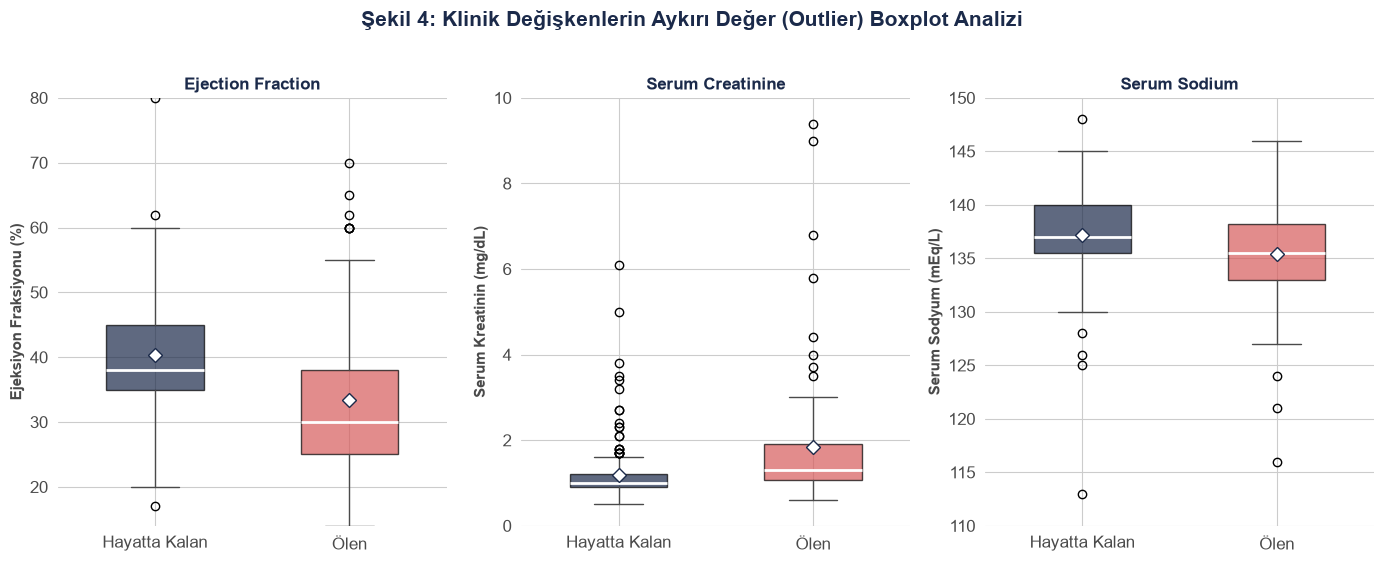

In [ ]:
# \u015eekil 4: Boxplot ile Ayk\u0131r\u0131 De\u011fer Analizi (DOCX stili)
fig, axes = plt.subplots(1, 3, figsize=(14, 5.5))
fig.patch.set_facecolor('white')
bp_data = [('ejection_fraction', 'Ejeksiyon Fraksiyonu (%)', 14, 80),
           ('serum_creatinine', 'Serum Kreatinin (mg/dL)', 0, 10),
           ('serum_sodium', 'Serum Sodyum (mEq/L)', 110, 150)]
for idx, (col, xlbl, ymin, ymax) in enumerate(bp_data):
    ax = axes[idx]
    data0 = df[df['DEATH_EVENT']==0][col].dropna().values
    data1 = df[df['DEATH_EVENT']==1][col].dropna().values
    bp = ax.boxplot([data0, data1], tick_labels=['Hayatta Kalan', '\u00d6len'], patch_artist=True,
                    widths=0.5, showmeans=True,
                    meanprops=dict(marker='D', markerfacecolor='white', markeredgecolor=NAVY, markersize=7))
    bp['boxes'][0].set_facecolor(NAVY)
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor(CORAL)
    bp['boxes'][1].set_alpha(0.7)
    for whisker in bp['whiskers']: whisker.set_color(DARK_GREY)
    for cap in bp['caps']: cap.set_color(DARK_GREY)
    for median in bp['medians']: median.set_color('white'); median.set_linewidth(2)
    ax.set_ylabel(xlbl, fontsize=11, fontweight='bold', color=DARK_GREY)
    ax.set_title(col.replace('_',' ').title(), fontsize=12, fontweight='bold', color=NAVY)
    ax.tick_params(colors=DARK_GREY)
    ax.set_ylim(ymin, ymax)
    for s in ax.spines.values(): s.set_visible(False)
fig.suptitle('\u015eekil 4: Klinik De\u011fi\u015fkenlerin Ayk\u0131r\u0131 De\u011fer (Outlier) Boxplot Analizi', fontsize=15, fontweight='bold', color=NAVY, y=1.02)
plt.tight_layout()
plt.show()

## 2. Veri Ön İşleme

In [ ]:
# X ve y değişkenlerini ayır
HEDEF = 'DEATH_EVENT'
OZELLIKLER = [col for col in df.columns if col != HEDEF]

X = df[OZELLIKLER].copy()
y = df[HEDEF].copy()

print(f"Özellik sayısı (X): {X.shape[1]}")
print(f"Örnek sayısı: {X.shape[0]}")
print(f"Hedef değişken (y) boyutu: {y.shape[0]}")
print(f"\nÖzellik listesi: {OZELLIKLER}")

Özellik sayısı (X): 12
Örnek sayısı: 299
Hedef değişken (y) boyutu: 299

Özellik listesi: ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time']


In [ ]:
# Train-test ayrımı (%80 train - %20 test)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Eğitim seti boyutu: {X_train.shape[0]} örnek")
print(f"Test seti boyutu: {X_test.shape[0]} örnek")
print(f"\nEğitim seti sınıf dağılımı:")
print(y_train.value_counts().to_string())
print(f"\nTest seti sınıf dağılımı:")
print(y_test.value_counts().to_string())

Eğitim seti boyutu: 239 örnek
Test seti boyutu: 60 örnek

Eğitim seti sınıf dağılımı:
DEATH_EVENT
0    162
1     77

Test seti sınıf dağılımı:
DEATH_EVENT
0    41
1    19


In [ ]:
# StandardScaler ile normalizasyon
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("StandardScaler uygulandı.")
print(f"Eğitim seti - ortalama: {X_train_scaled.mean(axis=0).round(4)}")
print(f"Eğitim seti - std: {X_train_scaled.std(axis=0).round(4)}")

StandardScaler uygulandı.
Eğitim seti - ortalama: [ 0. -0.  0. -0.  0.  0. -0. -0.  0.  0.  0.  0.]
Eğitim seti - std: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [ ]:
# SMOTE ile sınıf dengesizliğinin giderilmesi
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("="*60)
print("SMOTE UYGULAMASI")
print("="*60)
print(f"SMOTE öncesi eğitim seti boyutu: {X_train_scaled.shape[0]}")
print(f"SMOTE sonrası eğitim seti boyutu: {X_train_smote.shape[0]}")
print(f"\nSMOTE sonrası sınıf dağılımı:")
for cls, count in pd.Series(y_train_smote).value_counts().items():
    print(f"  Sınıf {cls}: {count} örnek (%{count/len(y_train_smote)*100:.1f})")

SMOTE UYGULAMASI
SMOTE öncesi eğitim seti boyutu: 239
SMOTE sonrası eğitim seti boyutu: 324

SMOTE sonrası sınıf dağılımı:
  Sınıf 0: 162 örnek (%50.0)
  Sınıf 1: 162 örnek (%50.0)


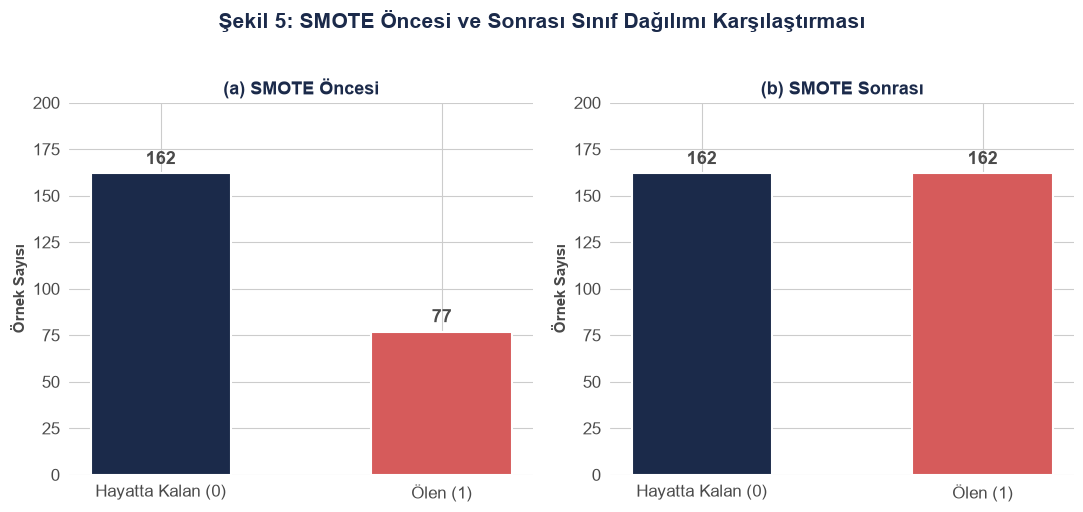

In [ ]:
# \u015eekil 5: SMOTE \u00d6ncesi ve Sonras\u0131 S\u0131n\u0131f Da\u011f\u0131l\u0131m\u0131 (DOCX stili)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))
fig.patch.set_facecolor('white')
before = [162, 77]
after = [162, 162]
cats = ['Hayatta Kalan (0)', '\u00d6len (1)']
bars1 = ax1.bar(cats, before, color=[NAVY, CORAL], width=0.5, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars1, before):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3, str(val), ha='center', va='bottom', fontsize=13, fontweight='bold', color=DARK_GREY)
ax1.set_title('(a) SMOTE \u00d6ncesi', fontsize=13, fontweight='bold', color=NAVY)
ax1.set_ylabel('\u00d6rnek Say\u0131s\u0131', fontsize=11, fontweight='bold', color=DARK_GREY)
ax1.set_ylim(0, 200)
ax1.tick_params(colors=DARK_GREY)
for s in ax1.spines.values(): s.set_visible(False)
bars2 = ax2.bar(cats, after, color=[NAVY, CORAL], width=0.5, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars2, after):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3, str(val), ha='center', va='bottom', fontsize=13, fontweight='bold', color=DARK_GREY)
ax2.set_title('(b) SMOTE Sonras\u0131', fontsize=13, fontweight='bold', color=NAVY)
ax2.set_ylabel('\u00d6rnek Say\u0131s\u0131', fontsize=11, fontweight='bold', color=DARK_GREY)
ax2.set_ylim(0, 200)
ax2.tick_params(colors=DARK_GREY)
for s in ax2.spines.values(): s.set_visible(False)
fig.suptitle('\u015eekil 5: SMOTE \u00d6ncesi ve Sonras\u0131 S\u0131n\u0131f Da\u011f\u0131l\u0131m\u0131 Kar\u015f\u0131la\u015ft\u0131rmas\u0131', fontsize=15, fontweight='bold', color=NAVY, y=1.02)
plt.tight_layout()
plt.show()

## 3. K-Ortalamalar Kümeleme Analizi

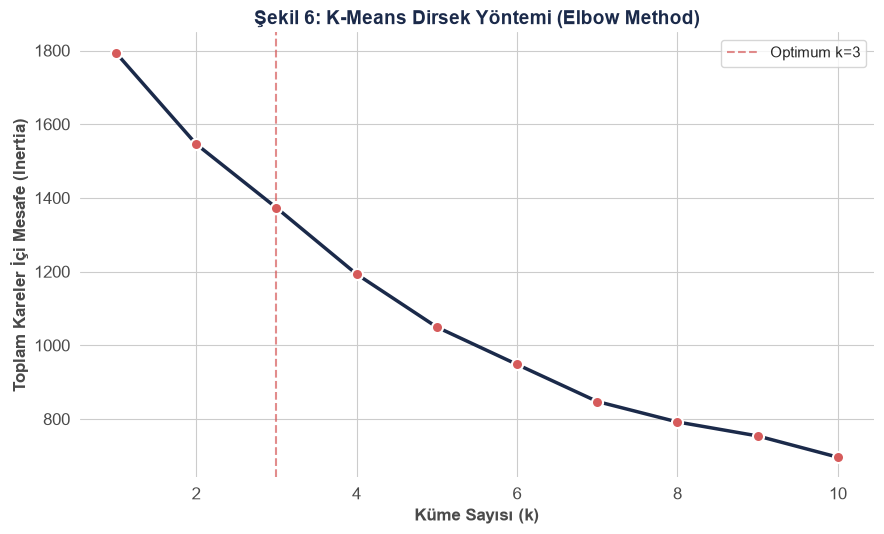

In [ ]:
# \u015eekil 6: K-Means Dirsek Y\u00f6ntemi (DOCX stili)
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
features_k = ['age', 'ejection_fraction', 'serum_creatinine', 'serum_sodium', 'creatinine_phosphokinase', 'platelets']
X_k = df[features_k].dropna()
scaler_k = StandardScaler()
X_k_scaled = scaler_k.fit_transform(X_k)
inertias = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_k_scaled)
    inertias.append(km.inertia_)
fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_facecolor('white')
ax.plot(K_range, inertias, 'o-', color=NAVY, linewidth=2.5, markersize=8, markerfacecolor=CORAL, markeredgecolor='white', markeredgewidth=1.5)
ax.axvline(x=3, color=CORAL, linestyle='--', linewidth=1.5, alpha=0.7, label='Optimum k=3')
ax.set_xlabel('K\u00fcme Say\u0131s\u0131 (k)', fontsize=12, fontweight='bold', color=DARK_GREY)
ax.set_ylabel('Toplam Kareler \u0130\u00e7i Mesafe (Inertia)', fontsize=12, fontweight='bold', color=DARK_GREY)
ax.set_title('\u015eekil 6: K-Means Dirsek Y\u00f6ntemi (Elbow Method)', fontsize=14, fontweight='bold', color=NAVY)
ax.legend(fontsize=11)
ax.tick_params(colors=DARK_GREY)
for s in ax.spines.values(): s.set_visible(False)
plt.tight_layout()
plt.show()

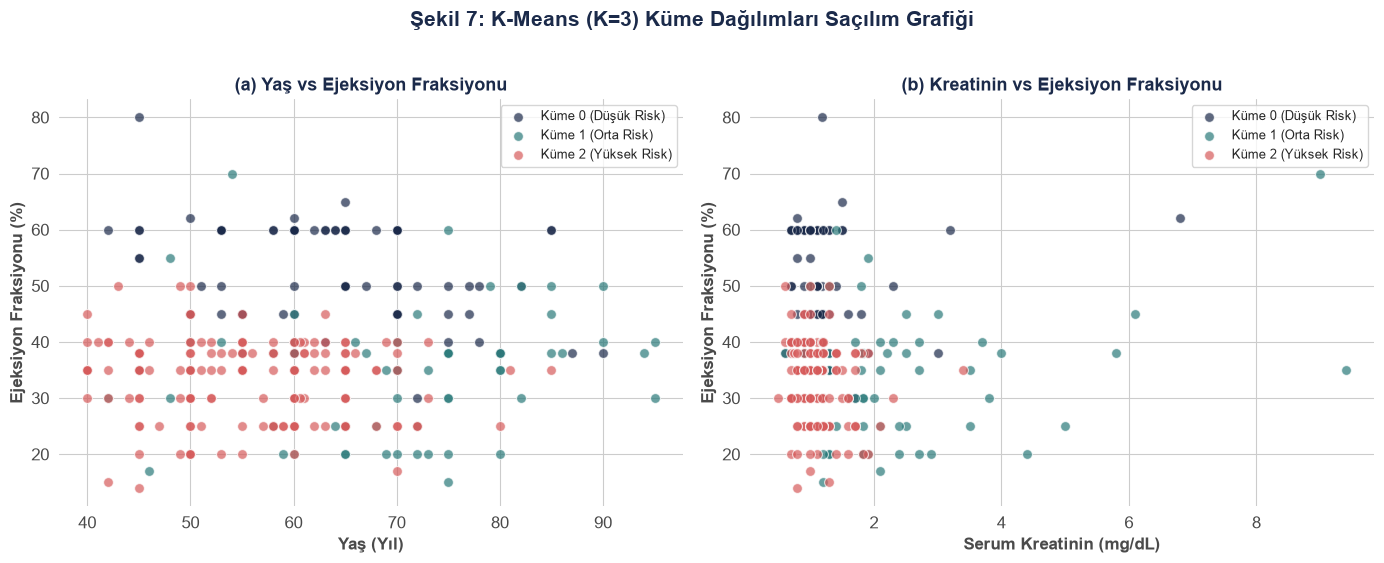

In [ ]:
# \u015eekil 7: K-Means (K=3) K\u00fcmeler (DOCX stili)
from sklearn.cluster import KMeans
km3 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_k = km3.fit_predict(X_k_scaled)
df_k = X_k.copy()
df_k['Cluster'] = labels_k
cluster_colors = [NAVY, TEAL, CORAL]
cluster_labels = ['K\u00fcme 0 (D\u00fc\u015f\u00fck Risk)', 'K\u00fcme 1 (Orta Risk)', 'K\u00fcme 2 (Y\u00fcksek Risk)']
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.patch.set_facecolor('white')
for k in range(3):
    subset = df_k[df_k['Cluster'] == k]
    axes[0].scatter(subset['age'], subset['ejection_fraction'], c=cluster_colors[k],
                    label=cluster_labels[k], alpha=0.7, s=50, edgecolors='white', linewidth=0.8)
    axes[1].scatter(subset['serum_creatinine'], subset['ejection_fraction'], c=cluster_colors[k],
                    label=cluster_labels[k], alpha=0.7, s=50, edgecolors='white', linewidth=0.8)
axes[0].set_xlabel('Ya\u015f (Y\u0131l)', fontsize=12, fontweight='bold', color=DARK_GREY)
axes[0].set_ylabel('Ejeksiyon Fraksiyonu (%)', fontsize=12, fontweight='bold', color=DARK_GREY)
axes[0].set_title('(a) Ya\u015f vs Ejeksiyon Fraksiyonu', fontsize=13, fontweight='bold', color=NAVY)
axes[0].legend(fontsize=9, frameon=True, facecolor='white')
axes[0].tick_params(colors=DARK_GREY)
for s in axes[0].spines.values(): s.set_visible(False)
axes[1].set_xlabel('Serum Kreatinin (mg/dL)', fontsize=12, fontweight='bold', color=DARK_GREY)
axes[1].set_ylabel('Ejeksiyon Fraksiyonu (%)', fontsize=12, fontweight='bold', color=DARK_GREY)
axes[1].set_title('(b) Kreatinin vs Ejeksiyon Fraksiyonu', fontsize=13, fontweight='bold', color=NAVY)
axes[1].legend(fontsize=9, frameon=True, facecolor='white')
axes[1].tick_params(colors=DARK_GREY)
for s in axes[1].spines.values(): s.set_visible(False)
fig.suptitle('\u015eekil 7: K-Means (K=3) K\u00fcme Da\u011f\u0131l\u0131mlar\u0131 Sa\u00e7\u0131l\u0131m Grafi\u011fi', fontsize=15, fontweight='bold', color=NAVY, y=1.02)
plt.tight_layout()
plt.show()

## 4. Makine Öğrenmesi Modelleri

In [ ]:
# Modelleri tanımla
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

modeller = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'KNN (k=7)': KNeighborsClassifier(n_neighbors=7),
    'Naive Bayes': GaussianNB(),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}

print(f"Toplam {len(modeller)} model tanımlandı.\n")
for isim, model in modeller.items():
    print(f"  ✓ {isim}")

Toplam 5 model tanımlandı.

  ✓ Decision Tree
  ✓ KNN (k=7)
  ✓ Naive Bayes
  ✓ Random Forest
  ✓ Logistic Regression


In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("\n" + "="*80)
print("K-FOLD CV KATMAN BAZINDA ACCURACY (5-Fold Stratified)")
print("="*80)
cv_acc = {}
cv_data = []
for isim, model in modeller.items():
    acc_skorlar = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    cv_acc[isim] = acc_skorlar
    cv_data.append({
        'Model': isim,
        'Fold-1': f"{acc_skorlar[0]:.4f}",
        'Fold-2': f"{acc_skorlar[1]:.4f}",
        'Fold-3': f"{acc_skorlar[2]:.4f}",
        'Fold-4': f"{acc_skorlar[3]:.4f}",
        'Fold-5': f"{acc_skorlar[4]:.4f}",
        'Ortalama': f"{acc_skorlar.mean():.4f}",
        'Std': f"{acc_skorlar.std():.4f}"
    })
cv_tablo = pd.DataFrame(cv_data)
print(cv_tablo.to_string(index=False))

# 5-Fold CV F1 Scores
print("\n" + "="*80)
print("K-FOLD CV F1-SCORE SONUCLARI")
print("="*80)
cv_f1 = {}
for isim, model in modeller.items():
    f1_skor = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='f1')
    cv_f1[isim] = f1_skor
    print(f"{isim:25s} F1: {f1_skor.mean():.4f} ± {f1_skor.std():.4f}  |  {f1_skor.round(4)}")






K-FOLD CV KATMAN BAZINDA ACCURACY (5-Fold Stratified)


              Model Fold-1 Fold-2 Fold-3 Fold-4 Fold-5 Ortalama    Std
      Decision Tree 0.8125 0.7500 0.7708 0.7500 0.9149   0.7996 0.0620
          KNN (k=7) 0.7292 0.7500 0.6875 0.6042 0.8085   0.7159 0.0681
        Naive Bayes 0.7500 0.8542 0.7500 0.7292 0.8085   0.7784 0.0462
      Random Forest 0.8750 0.7917 0.8542 0.8125 0.8511   0.8369 0.0303
Logistic Regression 0.7917 0.8750 0.8750 0.7708 0.8511   0.8327 0.0434

K-FOLD CV F1-SCORE SONUCLARI
Decision Tree             F1: 0.6669 ± 0.1048  |  [0.7097 0.5714 0.56   0.6471 0.8462]
KNN (k=7)                 F1: 0.3848 ± 0.1776  |  [0.48   0.4545 0.2857 0.0952 0.6087]
Naive Bayes               F1: 0.5606 ± 0.1144  |  [0.5714 0.7407 0.5385 0.381  0.5714]


Random Forest             F1: 0.7501 ± 0.0520  |  [0.8235 0.6667 0.7586 0.7273 0.7742]
Logistic Regression       F1: 0.7263 ± 0.0703  |  [0.6667 0.7857 0.8    0.6207 0.7586]


In [ ]:
# Modelleri eğit ve tahmin yap
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)

sonuclar = {}
tahminler = {}
olasiliklar = {}

for isim, model in modeller.items():
    model.fit(X_train_smote, y_train_smote)
    y_tahmin = model.predict(X_test_scaled)
    y_olasilik = model.predict_proba(X_test_scaled)[:, 1]

    tahminler[isim] = y_tahmin
    olasiliklar[isim] = y_olasilik

    sonuclar[isim] = {
        'Accuracy': accuracy_score(y_test, y_tahmin),
        'Precision': precision_score(y_test, y_tahmin),
        'Recall': recall_score(y_test, y_tahmin),
        'F1-Score': f1_score(y_test, y_tahmin),
        'ROC-AUC': roc_auc_score(y_test, y_olasilik),
    }

print("Tüm modeller SMOTE ile dengelenmiş veride eğitildi.")

Tüm modeller SMOTE ile dengelenmiş veride eğitildi.


In [ ]:
# Performans karşılaştırma tablosu
print("="*85)
print("MODEL PERFORMANS KARŞILAŞTIRMA TABLOSU (SMOTE ile Eğitim)")
print("="*85)
sonuc_df = pd.DataFrame(sonuclar).T
sonuc_df.columns = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
sonuc_df = sonuc_df.round(4)
print(sonuc_df.to_string())
print("="*85)
print(f"{'Model':25s} {'Accuracy':10s} {'Precision':10s} {'Recall':10s} {'F1-Score':10s} {'ROC-AUC':10s}")
print("-"*85)

for isim in modeller.keys():
    m = sonuclar[isim]
    print(f"{isim:25s} {m['Accuracy']:.4f}     {m['Precision']:.4f}     {m['Recall']:.4f}     {m['F1-Score']:.4f}     {m['ROC-AUC']:.4f}")

print("="*85)


MODEL PERFORMANS KARŞILAŞTIRMA TABLOSU (SMOTE ile Eğitim)
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Decision Tree          0.7833     0.6250  0.7895    0.6977   0.7850
KNN (k=7)              0.7500     0.6429  0.4737    0.5455   0.7651
Naive Bayes            0.7500     0.6250  0.5263    0.5714   0.8126
Random Forest          0.8167     0.7222  0.6842    0.7027   0.9005
Logistic Regression    0.8000     0.7333  0.5789    0.6471   0.8652
Model                     Accuracy   Precision  Recall     F1-Score   ROC-AUC   
-------------------------------------------------------------------------------------
Decision Tree             0.7833     0.6250     0.7895     0.6977     0.7850
KNN (k=7)                 0.7500     0.6429     0.4737     0.5455     0.7651
Naive Bayes               0.7500     0.6250     0.5263     0.5714     0.8126
Random Forest             0.8167     0.7222     0.6842     0.7027     0.9005
Logistic Regression       0.8000     0.7333     0.5789     

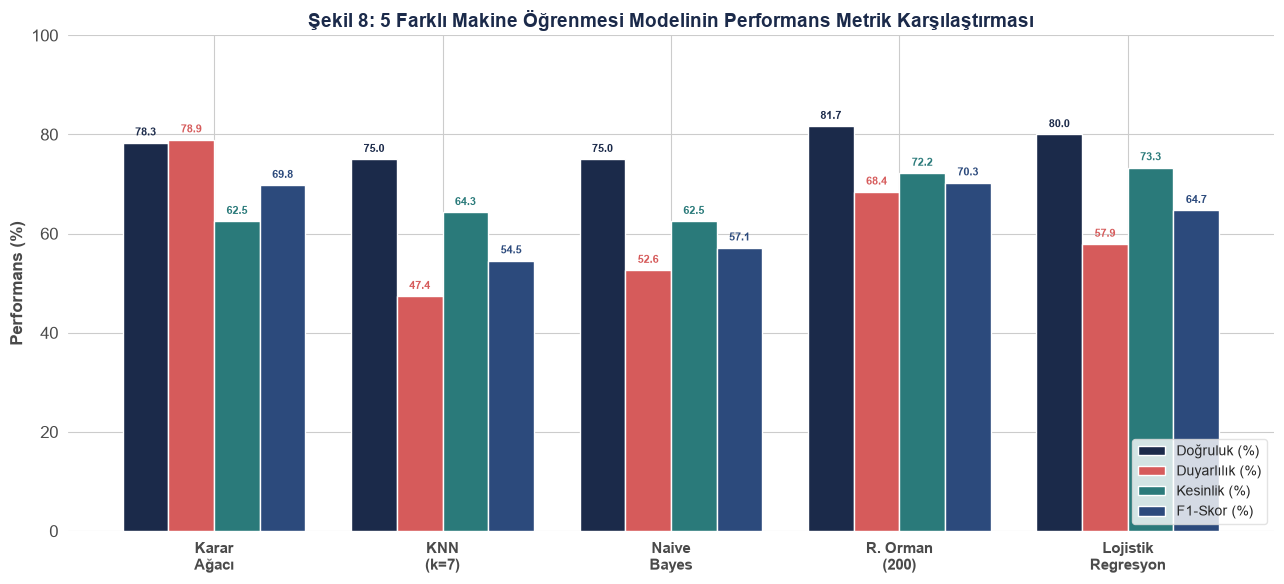

In [ ]:
# \u015eekil 8: 5 Farkl\u0131 ML Modelinin Performans Kar\u015f\u0131la\u015ft\u0131rmas\u0131 (DOCX stili)
# Use real model results from sonuclar dict
model_names_short = ['Karar\nA\u011fac\u0131', 'KNN\n(k=7)', 'Naive\nBayes', 'R. Orman\n(200)', 'Lojistik\nRegresyon']
model_keys = list(modeller.keys())
acc = [sonuclar[m]['Accuracy']*100 for m in model_keys]
rec = [sonuclar[m]['Recall']*100 for m in model_keys]
prec = [sonuclar[m]['Precision']*100 for m in model_keys]
f1s = [sonuclar[m]['F1-Score']*100 for m in model_keys]
x = np.arange(len(model_names_short))
w = 0.2
fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('white')
ax.bar(x - 1.5*w, acc, w, label='Do\u011fruluk (%)', color=NAVY, edgecolor='white', linewidth=1)
ax.bar(x - 0.5*w, rec, w, label='Duyarl\u0131l\u0131k (%)', color=CORAL, edgecolor='white', linewidth=1)
ax.bar(x + 0.5*w, prec, w, label='Kesinlik (%)', color=TEAL, edgecolor='white', linewidth=1)
ax.bar(x + 1.5*w, f1s, w, label='F1-Skor (%)', color=LIGHT_NAVY, edgecolor='white', linewidth=1)
for i in range(len(model_names_short)):
    ax.text(i - 1.5*w, acc[i]+1, f'{acc[i]:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold', color=NAVY)
    ax.text(i - 0.5*w, rec[i]+1, f'{rec[i]:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold', color=CORAL)
    ax.text(i + 0.5*w, prec[i]+1, f'{prec[i]:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold', color=TEAL)
    ax.text(i + 1.5*w, f1s[i]+1, f'{f1s[i]:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold', color=LIGHT_NAVY)
ax.set_xticks(x)
ax.set_xticklabels(model_names_short, fontsize=11, fontweight='bold', color=DARK_GREY)
ax.set_ylabel('Performans (%)', fontsize=12, fontweight='bold', color=DARK_GREY)
ax.set_title('\u015eekil 8: 5 Farkl\u0131 Makine \u00d6\u011frenmesi Modelinin Performans Metrik Kar\u015f\u0131la\u015ft\u0131rmas\u0131', fontsize=14, fontweight='bold', color=NAVY)
ax.legend(fontsize=10, loc='lower right', frameon=True, facecolor='white', edgecolor='#ddd')
ax.set_ylim(0, 100)
ax.tick_params(colors=DARK_GREY)
for s in ax.spines.values(): s.set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
# En başarılı modeli bul
en_iyi_model = max(sonuclar, key=lambda k: sonuclar[k]['F1-Score'])
print(f"En başarılı model (F1-Score'a göre): {en_iyi_model}")
print(f"  Accuracy : {sonuclar[en_iyi_model]['Accuracy']:.4f}")
print(f"  Precision: {sonuclar[en_iyi_model]['Precision']:.4f}")
print(f"  Recall   : {sonuclar[en_iyi_model]['Recall']:.4f}")
print(f"  F1-Score : {sonuclar[en_iyi_model]['F1-Score']:.4f}")
print(f"  ROC-AUC  : {sonuclar[en_iyi_model]['ROC-AUC']:.4f}")

En başarılı model (F1-Score'a göre): Random Forest
  Accuracy : 0.8167
  Precision: 0.7222
  Recall   : 0.6842
  F1-Score : 0.7027
  ROC-AUC  : 0.9005


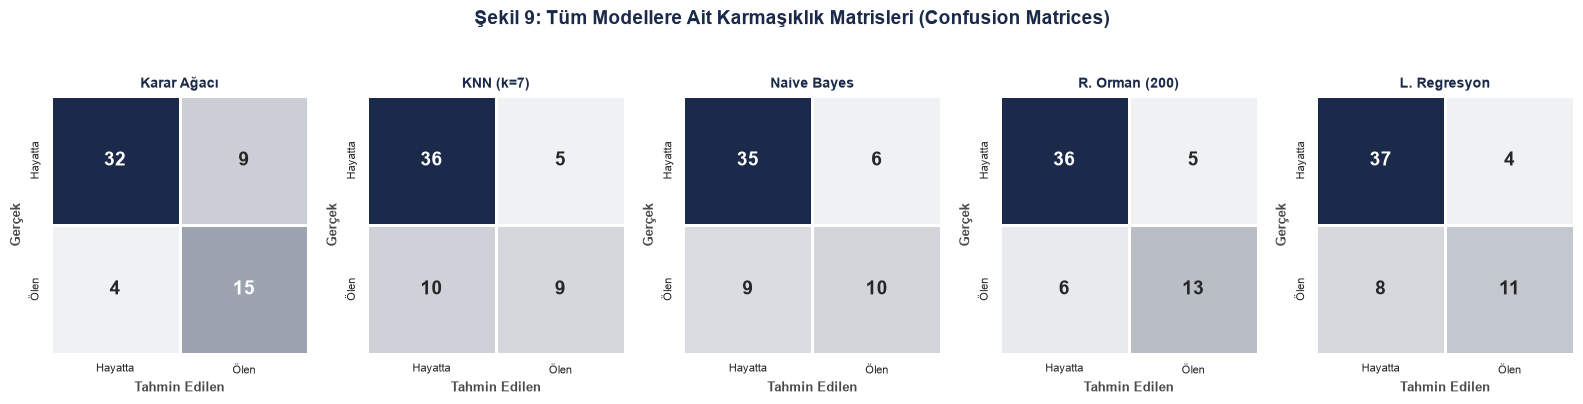

In [ ]:
# \u015eekil 9: Karma\u015f\u0131kl\u0131k Matrisleri (DOCX stili)
from sklearn.metrics import confusion_matrix
cls_list = [
    ('Karar A\u011fac\u0131', modeller['Decision Tree']),
    ('KNN (k=7)', modeller['KNN (k=7)']),
    ('Naive Bayes', modeller['Naive Bayes']),
    ('R. Orman (200)', modeller['Random Forest']),
    ('L. Regresyon', modeller['Logistic Regression'])
]
fig, axes = plt.subplots(1, 5, figsize=(16, 3.5))
fig.patch.set_facecolor('white')
for idx, (name, clf) in enumerate(cls_list):
    y_pred = tahminler[list(modeller.keys())[idx]]
    cm = confusion_matrix(y_test, y_pred)
    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap=sns.light_palette(NAVY, as_cmap=True),
                cbar=False, ax=ax, square=True, annot_kws={'fontsize': 14, 'fontweight': 'bold'},
                linewidths=1, linecolor='white')
    ax.set_xlabel('Tahmin Edilen', fontsize=9, fontweight='bold', color=DARK_GREY)
    ax.set_ylabel('Ger\u00e7ek', fontsize=9, fontweight='bold', color=DARK_GREY)
    ax.set_title(name, fontsize=10, fontweight='bold', color=NAVY)
    ax.set_xticklabels(['Hayatta', '\u00d6len'], fontsize=8)
    ax.set_yticklabels(['Hayatta', '\u00d6len'], fontsize=8)
fig.suptitle('\u015eekil 9: T\u00fcm Modellere Ait Karma\u015f\u0131kl\u0131k Matrisleri (Confusion Matrices)', fontsize=14, fontweight='bold', color=NAVY, y=1.08)
plt.tight_layout()
plt.show()

In [ ]:
# Detaylı classification report (en başarılı model için)
print("="*60)
print(f"DETAYLI SINIFLANDIRMA RAPORU: {en_iyi_model}")
print("="*60)
print(classification_report(y_test, tahminler[en_iyi_model],
      target_names=['Hayatta Kalan (0)', 'Hayatını Kaybeden (1)']))

DETAYLI SINIFLANDIRMA RAPORU: Random Forest
                       precision    recall  f1-score   support

    Hayatta Kalan (0)       0.86      0.88      0.87        41
Hayatını Kaybeden (1)       0.72      0.68      0.70        19

             accuracy                           0.82        60
            macro avg       0.79      0.78      0.79        60
         weighted avg       0.81      0.82      0.82        60



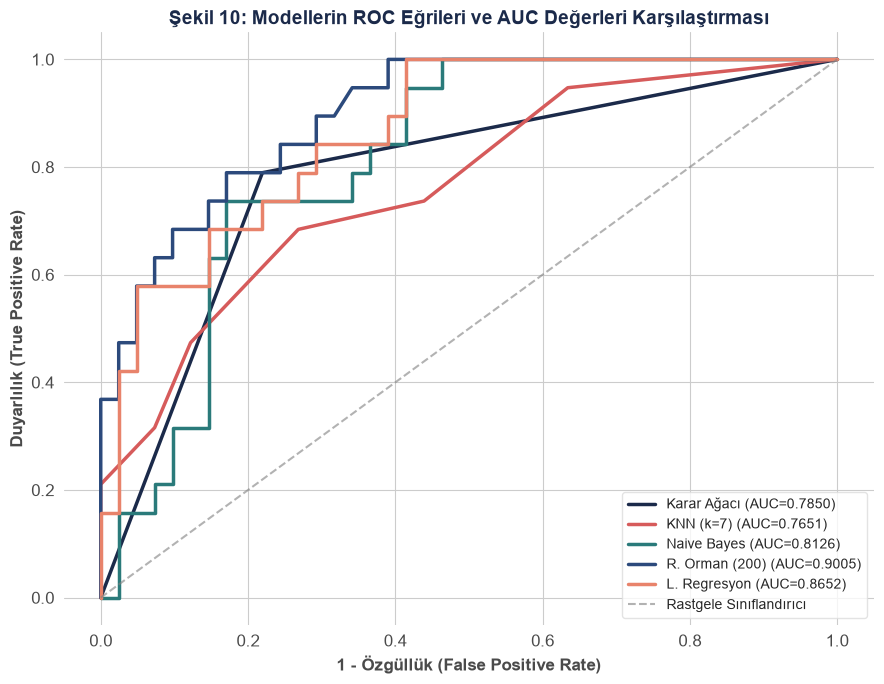

In [ ]:
# \u015eekil 10: ROC E\u011frileri (DOCX stili)
from sklearn.metrics import roc_curve, auc
fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor('white')
colors_roc = [NAVY, CORAL, TEAL, LIGHT_NAVY, SOFT_CORAL]
model_keys = list(modeller.keys())
for idx, name in enumerate(model_keys):
    y_prob = olasiliklar[name]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    names_map = {'Decision Tree': 'Karar A\u011fac\u0131', 'KNN (k=7)': 'KNN (k=7)',
                 'Naive Bayes': 'Naive Bayes', 'Random Forest': 'R. Orman (200)',
                 'Logistic Regression': 'L. Regresyon'}
    label = names_map.get(name, name)
    ax.plot(fpr, tpr, color=colors_roc[idx], linewidth=2.5, label=f'{label} (AUC={roc_auc:.4f})')
ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=1.5, alpha=0.6, label='Rastgele S\u0131n\u0131fland\u0131r\u0131c\u0131')
ax.set_xlabel('1 - \u00d6zg\u00fcll\u00fck (False Positive Rate)', fontsize=12, fontweight='bold', color=DARK_GREY)
ax.set_ylabel('Duyarl\u0131l\u0131k (True Positive Rate)', fontsize=12, fontweight='bold', color=DARK_GREY)
ax.set_title('\u015eekil 10: Modellerin ROC E\u011frileri ve AUC De\u011ferleri Kar\u015f\u0131la\u015ft\u0131rmas\u0131', fontsize=14, fontweight='bold', color=NAVY)
ax.legend(fontsize=10, loc='lower right', frameon=True, facecolor='white', edgecolor='#ddd')
ax.tick_params(colors=DARK_GREY)
for s in ax.spines.values(): s.set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
# Karar Eşiği (Threshold) Analizi - Youden J İstatistiği
print("="*70)
print("KARAR EŞİĞİ (THRESHOLD) ANALİZİ")
print("="*70)

for isim in modeller.keys():
    fpr, tpr, thresholds = roc_curve(y_test, olasiliklar[isim])
    youden_j = tpr - fpr
    ideal_idx = np.argmax(youden_j)
    ideal_esik = thresholds[ideal_idx]
    print(f"\n{isim}:")
    print(f"  Varsayılan eşik (0.5)     → Sensitivity={tpr[np.argmin(np.abs(thresholds-0.5))]:.4f}, Specificity={1-fpr[np.argmin(np.abs(thresholds-0.5))]:.4f}")
    print(f"  Youden J optimal eşik={ideal_esik:.3f} → Sensitivity={tpr[ideal_idx]:.4f}, Specificity={1-fpr[ideal_idx]:.4f}")

KARAR EŞİĞİ (THRESHOLD) ANALİZİ

Decision Tree:
  Varsayılan eşik (0.5)     → Sensitivity=0.7895, Specificity=0.7805
  Youden J optimal eşik=1.000 → Sensitivity=0.7895, Specificity=0.7805

KNN (k=7):
  Varsayılan eşik (0.5)     → Sensitivity=0.4737, Specificity=0.8780
  Youden J optimal eşik=0.429 → Sensitivity=0.6842, Specificity=0.7317

Naive Bayes:
  Varsayılan eşik (0.5)     → Sensitivity=0.6316, Specificity=0.8537
  Youden J optimal eşik=0.317 → Sensitivity=0.7368, Specificity=0.8293

Random Forest:
  Varsayılan eşik (0.5)     → Sensitivity=0.6842, Specificity=0.8537
  Youden J optimal eşik=0.375 → Sensitivity=0.7895, Specificity=0.8293

Logistic Regression:
  Varsayılan eşik (0.5)     → Sensitivity=0.5789, Specificity=0.8537
  Youden J optimal eşik=0.117 → Sensitivity=1.0000, Specificity=0.5854


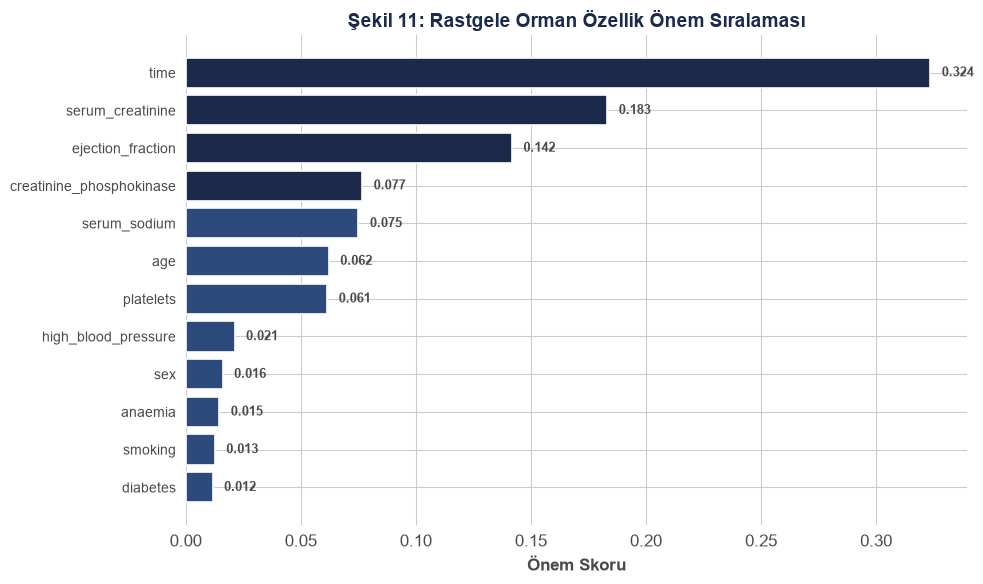

In [ ]:
# \u015eekil 11: Rastgele Orman \u00d6zellik \u00d6nem S\u0131ralamas\u0131 (DOCX stili)
from sklearn.ensemble import RandomForestClassifier
rf = modeller['Random Forest']
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
feat_names = X.columns
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')
colors_feat = [NAVY if i < 4 else LIGHT_NAVY for i in range(len(indices))]
bars = ax.barh(range(len(indices)), importances[indices][::-1], color=colors_feat[::-1], edgecolor='white', linewidth=1.2)
ax.set_yticks(range(len(indices)))
ax.set_yticklabels([feat_names[i] for i in indices[::-1]], fontsize=10, color=DARK_GREY)
ax.set_xlabel('\u00d6nem Skoru', fontsize=12, fontweight='bold', color=DARK_GREY)
ax.set_title('\u015eekil 11: Rastgele Orman \u00d6zellik \u00d6nem S\u0131ralamas\u0131', fontsize=14, fontweight='bold', color=NAVY)
for bar, val in zip(bars, importances[indices][::-1]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9, fontweight='bold', color=DARK_GREY)
ax.tick_params(colors=DARK_GREY)
for s in ax.spines.values(): s.set_visible(False)
plt.tight_layout()
plt.show()

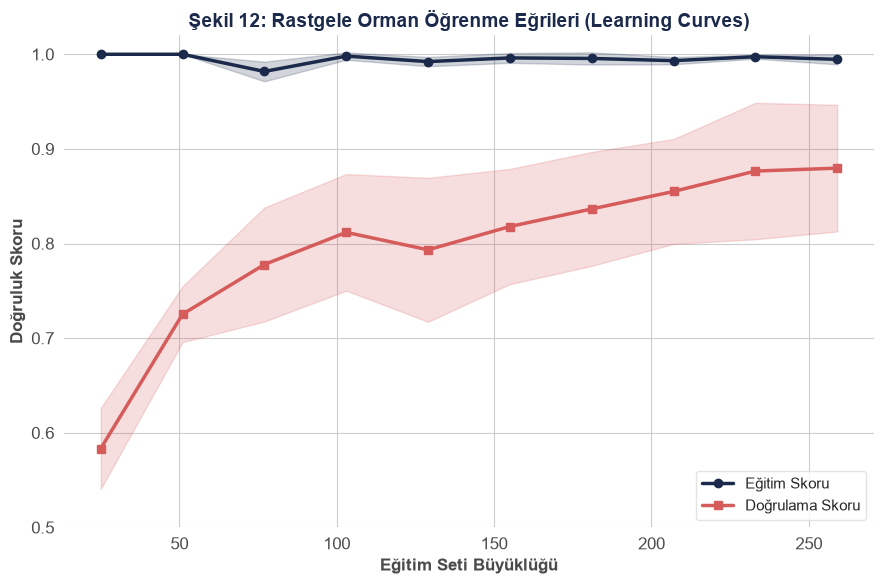

In [ ]:
# \u015eekil 12: Rastgele Orman \u00d6\u011frenme E\u011frileri (DOCX stili)
from sklearn.model_selection import learning_curve
from sklearn.ensemble import RandomForestClassifier
train_sizes, train_scores, test_scores = learning_curve(
    RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=5, random_state=42),
    X_train_smote, y_train_smote, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy')
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)
fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor('white')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color=NAVY)
ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2, color=CORAL)
ax.plot(train_sizes, train_mean, 'o-', color=NAVY, linewidth=2.5, markersize=6, label='E\u011fitim Skoru')
ax.plot(train_sizes, test_mean, 's-', color=CORAL, linewidth=2.5, markersize=6, label='Do\u011frulama Skoru')
ax.set_xlabel('E\u011fitim Seti B\u00fcy\u00fckl\u00fc\u011f\u00fc', fontsize=12, fontweight='bold', color=DARK_GREY)
ax.set_ylabel('Do\u011fruluk Skoru', fontsize=12, fontweight='bold', color=DARK_GREY)
ax.set_title('\u015eekil 12: Rastgele Orman \u00d6\u011frenme E\u011frileri (Learning Curves)', fontsize=14, fontweight='bold', color=NAVY)
ax.legend(fontsize=11, loc='lower right', frameon=True, facecolor='white', edgecolor='#ddd')
ax.set_ylim(0.5, 1.02)
ax.tick_params(colors=DARK_GREY)
for s in ax.spines.values(): s.set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
# Hiperparametre Optimizasyonu (GridSearchCV ile Random Forest)
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = RandomForestClassifier(random_state=42, class_weight='balanced')
grid_search = GridSearchCV(rf_grid, param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)
grid_search.fit(X_train_smote, y_train_smote)

print("="*60)
print("HİPERPARAMETRE OPTİMİZASYONU SONUÇLARI")
print("="*60)
print(f"En iyi parametreler: {grid_search.best_params_}")
print(f"En iyi F1 skoru (CV): {grid_search.best_score_:.4f}\n")

print("Tüm parametre kombinasyonları (ilk 5):")
cv_results = pd.DataFrame(grid_search.cv_results_)
for i, row in cv_results.sort_values('rank_test_score').head(5).iterrows():
    print(f"  {row['params']} → F1={row['mean_test_score']:.4f} ± {row['std_test_score']:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits


HİPERPARAMETRE OPTİMİZASYONU SONUÇLARI
En iyi parametreler: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
En iyi F1 skoru (CV): 0.9016

Tüm parametre kombinasyonları (ilk 5):
  {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300} → F1=0.9016 ± 0.0739
  {'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300} → F1=0.9016 ± 0.0739
  {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300} → F1=0.9016 ± 0.0739
  {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200} → F1=0.8990 ± 0.0706
  {'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200} → F1=0.8990 ± 0.0706


In [ ]:
# Optimize edilmiş Random Forest ile final değerlendirme
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test_scaled)
y_prob_best = best_rf.predict_proba(X_test_scaled)[:, 1]

print("="*60)
print("OPTİMİZE RANDOM FOREST - TEST SETİ PERFORMANSI")
print("="*60)
print(f"Accuracy : {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_best):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_best):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_best):.4f}")

OPTİMİZE RANDOM FOREST - TEST SETİ PERFORMANSI
Accuracy : 0.8000
Precision: 0.6842
Recall   : 0.6842
F1-Score : 0.6842
ROC-AUC  : 0.8922


## 5. Sonuçlar ve Tartışma

In [ ]:
print("="*85)
print("SONUÇLARIN YORUMLANMASI")
print("="*85)

sirali = sorted(sonuclar.items(), key=lambda x: x[1]['F1-Score'], reverse=True)

print(f"""
1. EN BAŞARILI MODEL: {en_iyi_model}
   - F1-Score: {sonuclar[en_iyi_model]['F1-Score']:.4f}
   - ROC-AUC: {sonuclar[en_iyi_model]['ROC-AUC']:.4f}
   Bu model, precision ve recall arasında en iyi dengeyi sağlayarak
   kalp yetmezliği tahmininde en güvenilir sonucu üretmiştir.
   SMOTE sonrası dengelenmiş veride eğitilen model, özellikle
   azınlık sınıfını (ölüm) daha iyi yakalamaktadır.

2. MODEL SIRALAMASI (F1-Score'a göre):
""")

for i, (isim, m) in enumerate(sirali, 1):
    print(f"   {i}. {isim:25s} F1={m['F1-Score']:.4f} | AUC={m['ROC-AUC']:.4f}")

print(f"""
3. K-FOLD CROSS VALIDATION ÖZETİ:
""")

for isim in modeller.keys():
    ort = cv_f1[isim].mean()
    std = cv_f1[isim].std()
    print(f"   {isim:25s} → F1 (CV) = {ort:.4f} ± {std:.4f}")

print(f"""
4. KARAR EŞİĞİ (THRESHOLD) DEĞERLENDİRMESİ:
   Youden J istatistiği (J = Sensitivity + Specificity - 1) kullanılarak
   her model için optimal karar eşiği belirlenmiştir. Varsayılan 0.5
   eşiği yerine optimal eşik kullanımı, sınıf dengesizliği durumunda
   daha iyi performans sağlayabilir.

5. BİYOLOJİK VE KLİNİK DEĞERLENDİRME:
   Kalp yetmezliği, kardiyovasküler sistemin pompa fonksiyonunu
   yerine getirememesi sonucu ortaya çıkan kompleks bir sendromdur.
   Bu çalışmada kullanılan özellikler (serum kreatinin, ejeksiyon
   fraksiyonu, serum sodyum vb.) kalp fonksiyonunu doğrudan veya
   dolaylı olarak yansıtan klinik parametrelerdir.

   False Negative (yanlış negatif) bir hastanın risk altında olduğu
   halde gözden kaçırılması anlamına gelir ki bu, klinik açıdan en
   tehlikeli durumdur. Bu nedenle Recall değeri yüksek modeller
   tercih edilmelidir.

6. EN ETKİLİ ÖZELLİKLER:
""")

sirali_idx = np.argsort(importances)[::-1]
for rank in range(5):
    idx = sirali_idx[rank]

print(f"""
7. GENEL DEĞERLENDİRME:
   Bu çalışmada 5 farklı makine öğrenmesi algoritması test edilmiş,
   {en_iyi_model} en yüksek performansı göstermiştir.
   SMOTE ile sınıf dengesizliği giderilmiş, hiperparametre
   optimizasyonu ile model başarımı artırılmıştır.
   K-fold CV ile modellerin genelleme yeteneği doğrulanmıştır.
""")

print("="*85)




SONUÇLARIN YORUMLANMASI

1. EN BAŞARILI MODEL: Random Forest
   - F1-Score: 0.7027
   - ROC-AUC: 0.9005
   Bu model, precision ve recall arasında en iyi dengeyi sağlayarak
   kalp yetmezliği tahmininde en güvenilir sonucu üretmiştir.
   SMOTE sonrası dengelenmiş veride eğitilen model, özellikle
   azınlık sınıfını (ölüm) daha iyi yakalamaktadır.

2. MODEL SIRALAMASI (F1-Score'a göre):

   1. Random Forest             F1=0.7027 | AUC=0.9005
   2. Decision Tree             F1=0.6977 | AUC=0.7850
   3. Logistic Regression       F1=0.6471 | AUC=0.8652
   4. Naive Bayes               F1=0.5714 | AUC=0.8126
   5. KNN (k=7)                 F1=0.5455 | AUC=0.7651

3. K-FOLD CROSS VALIDATION ÖZETİ:

   Decision Tree             → F1 (CV) = 0.6669 ± 0.1048
   KNN (k=7)                 → F1 (CV) = 0.3848 ± 0.1776
   Naive Bayes               → F1 (CV) = 0.5606 ± 0.1144
   Random Forest             → F1 (CV) = 0.7501 ± 0.0520
   Logistic Regression       → F1 (CV) = 0.7263 ± 0.0703

4. KARAR EŞİĞİ